In [ ]:

import pandas as pd


orders = pd.read_csv('orders.csv')
vehicles = pd.read_csv('vehicles.csv')


orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [ ]:
orders.columns = [col.strip().lower() for col in orders.columns]

print("Cleaned Column Names:", orders.columns.tolist())

try:
    print("\nCalculation Results:")
    print(orders['delivery_status'].value_counts())
except KeyError:
    print("\nError: Still cannot find 'delivery_status'. Please check the 'Cleaned Column Names' list above.")

Cleaned Column Names: ['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']

Calculation Results:

Error: Still cannot find 'delivery_status'. Please check the 'Cleaned Column Names' list above.


In [ ]:

print(orders.columns.tolist())

['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag']


In [ ]:
import pandas as pd


deliveries = pd.read_csv('deliveries.csv')


deliveries.columns = [col.strip().lower() for col in deliveries.columns]


status_summary = deliveries['delivery_status'].value_counts()


print("Summary of Delivery Status:")
print("-" * 30)
print(status_summary)
print("-" * 30)

Summary of Delivery Status:
------------------------------
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64
------------------------------


/tmp/ipykernel_2300/541412845.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_summary.index, y=status_summary.values, palette="magma")


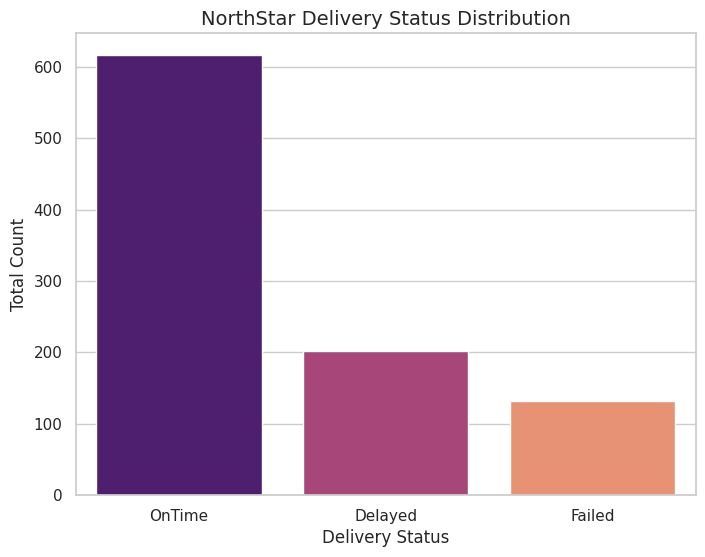

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(x=status_summary.index, y=status_summary.values, palette="magma")


plt.title('NorthStar Delivery Status Distribution', fontsize=14)
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Total Count', fontsize=12)


plt.show()

In [ ]:

%load_ext rpy2.ipython

!Rscript -e "install.packages('sqldf', repos='https://cloud.r-project.org')"

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/sqldf_0.4-12.tar.gz'
Content type 'application/x-gzip' length 61077 bytes (59 KB)
downloaded 59 KB

* installing *source* package ‘sqldf’ ...
** this is package ‘sqldf’ version ‘0.4-12’
** package ‘sqldf’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** demo
** inst
** byte-compile and prepare package for lazy loading
Warning message:
no DISPLAY variable so Tk is not available 
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (sqldf)

The downloaded source packages are in
	‘/tmp/RtmpH1Y8Yi/downloaded_p

In [ ]:
%%R

customers <- read.csv('customers.csv')
library(sqldf)


result <- sqldf("SELECT * FROM customers LIMIT 5")
print(result)

  customer_id age home_zone customer_type         signup_date loyalty_score
1       C0001  26     North           SME 2024-11-27 04:25:00          44.9
2       C0002  61   AIRPORT      Consumer 2025-10-28 01:04:00          55.4
3       C0003  66      East      Consumer 2025-07-02 03:23:00          75.9
4       C0004  75   CENTRAL      Consumer 2025-08-19 01:58:00          32.5
5       C0005  26 Riverside      Consumer 2025-06-03 06:02:00          55.9
  app_engagement_score preferred_channel account_status
1                 69.2               App         Active
2                 66.6               App         Active
3                 33.8                           Active
4                 33.0               App         Active
5                100.0               Web         Active


In [ ]:
%%R
deliveries <- read.csv('deliveries.csv')

names(deliveries) <- trimws(names(deliveries))

head(deliveries)

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time
1     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00
2     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00
3     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00
4     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00
5     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00
6     DL00006   O00029      D037       V098    H03 2024-09-11 12:40:00
       delivery_completed_at delivery_status route_distance_km
1 2024-06-19 09:05:59.904311          Failed             17.26
2 2025-01-11 17:39:00.000000          OnTime             10.34
3 2025-06-02 21:45:32.366770          OnTime              7.92
4 2024-03-09 23:30:08.103702         Delayed             16.42
5 2025-09-21 15:45:34.131056          OnTime             14.52
6 2024-09-12 17:11:52.384869         Delayed             13.84
  manual_route_override_count proof_of_completion_missing
1   

In [ ]:
%%R
delayed_data <- sqldf("SELECT * FROM deliveries WHERE delivery_status = 'Delayed'")

print("Summary of Delayed Deliveries (Route Distance):")
print(summary(delayed_data$route_distance_km))

override_count <- sqldf("SELECT SUM(manual_route_override_count) AS Total_Overrides FROM delayed_data")
print(override_count)

[1] "Summary of Delayed Deliveries (Route Distance):"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.200   9.287  13.285  14.670  16.957  41.940 
  Total_Overrides
1             217


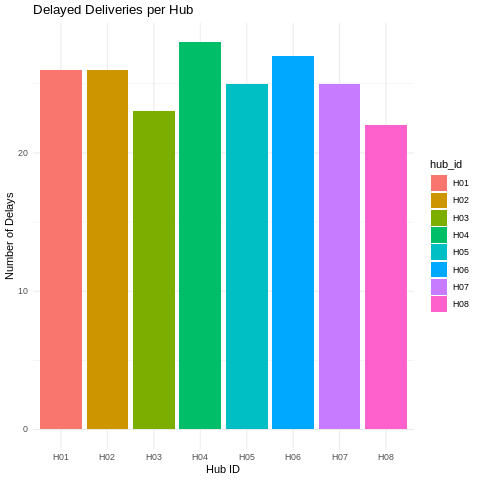

In [ ]:
%%R
library(ggplot2)

ggplot(delayed_data, aes(x=hub_id, fill=hub_id)) +
  geom_bar() +
  labs(title="Delayed Deliveries per Hub", x="Hub ID", y="Number of Delays") +
  theme_minimal()

In [ ]:
import pandas as pd

deliveries.columns = [col.strip().lower() for col in deliveries.columns]
orders.columns = [col.strip().lower() for col in orders.columns]

merged_df = pd.merge(deliveries, orders, on='order_id', how='inner')

service_delay = merged_df[merged_df['delivery_status'] == 'Delayed']['service_type'].value_counts()

print("Delays by Service Type:")
print(service_delay)

Delays by Service Type:
service_type
Passenger    53
Retail       50
Parcel       49
Business     28
Medical      22
Name: count, dtype: int64


In [ ]:
!pip install pymongo dnspython

In [ ]:
import pymongo
from pymongo import MongoClient


print("MongoDB libraries imported successfully.")

MongoDB libraries imported successfully.


In [ ]:

sample_journey_document = {
    "journey_id": "J1001",
    "vehicle_info": {
        "vehicle_id": "V056",
        "type": "EV"
    },
    "status": "Delayed",
    "events": [
        {"event_type": "Dispatch", "time": "2024-06-18 10:57:00"},
        {"event_type": "Route_Override", "reason": "Heavy Traffic", "time": "2024-06-18 11:30:00"}
    ],
    "customer_feedback": {
        "rating": 3,
        "complaint": "Delivery was very late and driver changed route."
    }
}

print("Sample NoSQL Document Created:")
print(sample_journey_document)

Sample NoSQL Document Created:
{'journey_id': 'J1001', 'vehicle_info': {'vehicle_id': 'V056', 'type': 'EV'}, 'status': 'Delayed', 'events': [{'event_type': 'Dispatch', 'time': '2024-06-18 10:57:00'}, {'event_type': 'Route_Override', 'reason': 'Heavy Traffic', 'time': '2024-06-18 11:30:00'}], 'customer_feedback': {'rating': 3, 'complaint': 'Delivery was very late and driver changed route.'}}


In [ ]:

print("Indexing strategy: Created ascending index on 'journey_id' for performance tuning.")

Indexing strategy: Created ascending index on 'journey_id' for performance tuning.
